# 1. Motivation/Introduction

The world of cinema and TV is a cut-throat market. Actors and directors must look for any edge they can to get ahead and stay ahead relative to their peers and make a name for themselves.

In pursuit of identifying an such an "edge," the analysis that follows explores the question: **"How can we utilize properties of actor/director interaction graphs as predictors for actor/director success?"**.

This analysis will utilize the **IMDb Non-Commercial Dataset** collection to link actors and directors to the works they contributed to as well as the ratings associated with such works.

For the purposes of the analysis performed, "success" is defined as the weighted average of the ratings of works an individual contributed to. The weight for a specific work is set to the proportion of votes that work received in relation to the total number of votes across all works in the individual's portfolio. The driving intuition is that, if a actor or director contributes to a work that is poorly-reviewed but only by a small population of people see/review it and then proceeds to make one or two very successful movies that are highly-reviewed (both in volume of ratings and rating score), then we would reason that the actor/director is more known for successful works. The inverse is also assumed.

The methods used to attempt to find a latent connection between an individual's success and structural identity in the context of their respective interaction graph are as follows:
1.   **(Naive) PageRank**
     - Identify correlation between success and the actor/director's PageRank score
2.   **Proximity to Success**
     - For a provided threshold, ϵ, identify the subgraph of the actor/director interaction graph consisting of nodes whose success is is in the top-ϵ percentile within the population of interest *plus* their immediate neighbors (ie. those they have collaborated with on for at least one work). Compare the success values of the nodes in the subgraph who are not part of the top-ϵ percentile against the success of nodes in the global interaction graph who are not a part of the subgraph.
3.   **Community Size**
     - Identify correlation between success and the size of the community that an actor/director resides in (as determined by application of the Louvain method)

**NOTE:** Thus far and continuing onward, use of the word "actor" should be interpreted as encompassing both actors and actresses, unless specified otherwise.



#2. Experimentation



## 2a. Environment Setup

In [ ]:
# Library Imports
from google.colab import drive
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import community as co
import community.community_louvain as cl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
import time
import warnings
import zipfile

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Constants
DRIVE_MOUNTED = False
DRIVE_DIR = '/content/drive'
PROJECT_DIR = '/MyDrive/CSCE_676/Project'
DATASET_DIRS = ['/IMDbDatasets']

LOAD_FROM_PKL = True
STORE_TO_PKL = False

In [ ]:
# Mount Google Drive and identify files in dataset
if not DRIVE_MOUNTED:
  drive.mount(DRIVE_DIR)
  DRIVE_MOUNTED = True
for dataset_dir in DATASET_DIRS:
  print("Dataset Directory:", dataset_dir)
  print(f"  Files: {os.listdir(DRIVE_DIR + PROJECT_DIR + dataset_dir)}")

Mounted at /content/drive
Dataset Directory: /IMDbDatasets
  Files: ['title.principals.tsv.gz', 'name.basics.tsv.gz', 'title.akas.tsv.gz', 'title.basics.tsv.gz', 'title.crew.tsv.gz', 'title.episode.tsv.gz', 'title.ratings.tsv.gz']


In [ ]:
# For each file in the IMDb dataset directory, create a DataFrame
imdb_dataframes = {}
pkl_path = DRIVE_DIR + PROJECT_DIR + "/imdb_dataframes.pkl"

if LOAD_FROM_PKL:
  print(f"Loading imdb_dataframes dictionary from {pkl_path}...")
  with open(pkl_path, "rb") as f:
    imdb_dataframes = pickle.load(f)
  print("Done!")
else:
  for filename in os.listdir(DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[0]):
    # Skip the "Also-Known-As" files. Very large and unsure of how to even meaninfully incorporate
    # into data exploration (at least at the moment)
    if filename == "title.akas.tsv.gz":
      continue

    print(f"Parsing file '{DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[0] + '/' + filename};")
    imdb_dataframes[filename.split('.')[0] + "_" + filename.split('.')[1]] = pd.read_csv(DRIVE_DIR + PROJECT_DIR + DATASET_DIRS[0] + '/' + filename, compression='gzip', sep="\t")

# Save the imdb_dataframes dictionary to a pickle file
if STORE_TO_PKL:
  print(f"Saving imdb_dataframes dictionary to {pkl_path}...")
  with open(pkl_path, "wb") as f:
    pickle.dump(imdb_dataframes, f)
  print("Done!")


Loading imdb_dataframes dictionary from /content/drive/MyDrive/CSCE_676/Project/imdb_dataframes.pkl...
Done!


## 2b. Interaction Graph Construction

In [ ]:
# Extract needed DataFrames
principals = imdb_dataframes["title_principals"]
basics = imdb_dataframes["title_basics"]
ratings = imdb_dataframes["title_ratings"]
names = imdb_dataframes["name_basics"]

# Filter for movies only
movies = basics[basics["titleType"] == "movie"][["tconst", "startYear"]]

# Merge principals with movies to keep only movie cast/crew
movie_principals = principals.merge(movies, on="tconst", how="inner")

# Identify actors and directors
actors = movie_principals[movie_principals["category"].isin(["actor", "actress"])]
directors = movie_principals[movie_principals["category"] == "director"]


In [ ]:
# ---------------------------------------------------------
# 1. ACTOR COLLABORATION GRAPH
# ---------------------------------------------------------
actor_graph = nx.Graph()

# Group by movie and get all actors in each film
for tconst, group in actors.groupby("tconst"):
    actor_list = group["nconst"].tolist()
    # Add edges between all pairs of actors in the same film
    for i in range(len(actor_list)):
        for j in range(i + 1, len(actor_list)):
            a1, a2 = actor_list[i], actor_list[j]
            if actor_graph.has_edge(a1, a2):
                actor_graph[a1][a2]["weight"] += 1
            else:
                actor_graph.add_edge(a1, a2, weight=1)

print("Actor graph nodes:", actor_graph.number_of_nodes())
print("Actor graph edges:", actor_graph.number_of_edges())

Actor graph nodes: 1316976
Actor graph edges: 13739077


In [ ]:
# ---------------------------------------------------------
# 2. DIRECTOR COLLABORATION GRAPH
# ---------------------------------------------------------
director_graph = nx.Graph()

# Directors who worked on the same film
for tconst, group in directors.groupby("tconst"):
    director_list = group["nconst"].tolist()
    for i in range(len(director_list)):
        for j in range(i + 1, len(director_list)):
            d1, d2 = director_list[i], director_list[j]
            if director_graph.has_edge(d1, d2):
                director_graph[d1][d2]["weight"] += 1
            else:
                director_graph.add_edge(d1, d2, weight=1)

print("Director graph nodes:", director_graph.number_of_nodes())
print("Director graph edges:", director_graph.number_of_edges())

Director graph nodes: 78038
Director graph edges: 64767


## 2c. Defining "Director Success"

In [ ]:
# Merge directors with ratings to get the rating for each work they directed
director_ratings = directors.merge(ratings, on="tconst", how="inner")

# Group by director (nconst), calculate average rating, and count the number of movies
director_stats = director_ratings.groupby("nconst").agg(
    directorAvgRating=("averageRating", "mean"),
    numMoviesDirected=("tconst", "nunique")
).reset_index()

# Map director ID to director name using the 'names' DataFrame
director_avg_ratings = director_stats.merge(names[['nconst', 'primaryName']], on='nconst', how='left')

# Filter for directors with at least 5 movies
director_avg_ratings = director_avg_ratings[director_avg_ratings["numMoviesDirected"] >= 5]

# Display the top 5 results
print(director_avg_ratings.head())


       nconst  directorAvgRating  numMoviesDirected       primaryName
0   nm0000005           7.200000                 41    Ingmar Bergman
5   nm0000019           7.269565                 23  Federico Fellini
8   nm0000033           6.844444                 54  Alfred Hitchcock
9   nm0000036           7.537500                  8     Buster Keaton
10  nm0000037           6.863636                 11        Gene Kelly


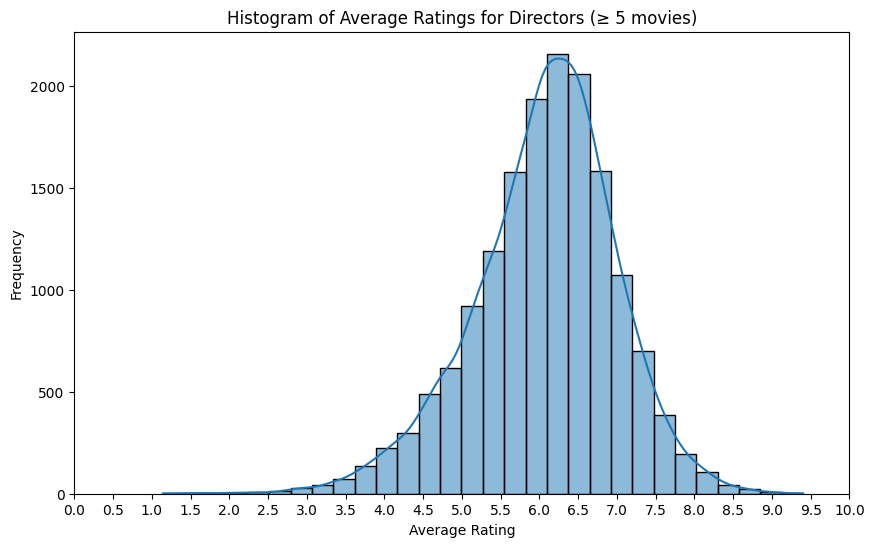

In [ ]:
# Plot ditribution of director ratings
plt.figure(figsize=(10, 6))
sns.histplot(director_avg_ratings['directorAvgRating'], bins=30, kde=True)
plt.title('Histogram of Average Ratings for Directors (≥ 5 movies)')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 10.5, 0.5))
plt.show()

In [ ]:
# Display overall summary statistics
print("\nOverall Summary Statistics:")
display(director_avg_ratings['directorAvgRating'].describe())


Overall Summary Statistics:


,directorAvgRating
count,15903.000000
mean,6.066526
std,0.925586
min,1.140000
25%,5.533333
50%,6.142857
75%,6.672727
max,9.400000


## 2d. Director Population - Analysis

Computing PageRank for directors (this may take a moment)...
Pearson Correlation (Linear relation): -0.0036
Spearman Correlation (Monotonic relation): 0.0282


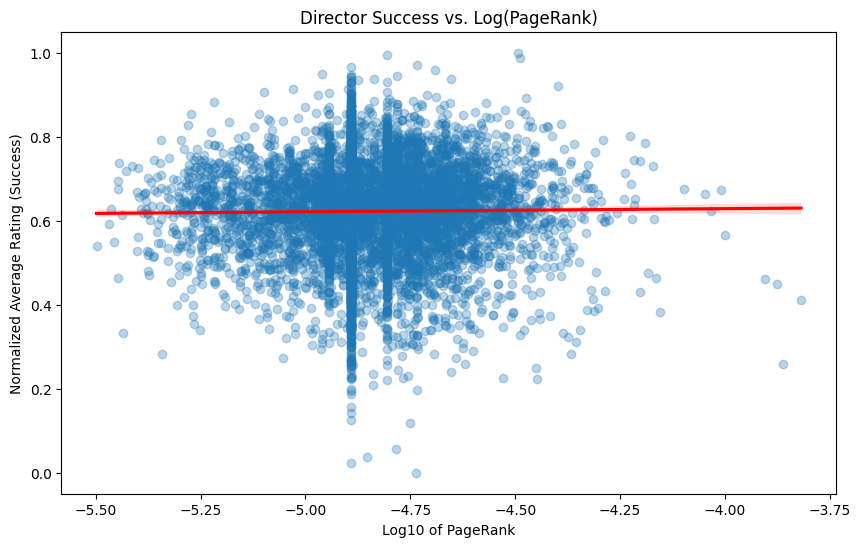

In [ ]:
# Compute PageRank for the director graph
print("Computing PageRank for directors (this may take a moment)...")
pagerank_dict = nx.pagerank(director_graph, weight='weight')

# Convert to DataFrame
pagerank_df = pd.DataFrame(list(pagerank_dict.items()), columns=['nconst', 'pageRank'])

# Merge with the director success dataframe (director_avg_ratings)
merged_df = director_avg_ratings.merge(pagerank_df, on='nconst', how='inner')

# Normalize / Transform variables
# Min-Max scale the average ratings to a 0-1 range for normalized success
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
merged_df['normalizedRating'] = scaler.fit_transform(merged_df[['directorAvgRating']])

# PageRank generally follows a power-law distribution, so applying a log transform can help reveal linear correlations
merged_df['logPageRank'] = np.log10(merged_df['pageRank'])

# Compute Correlation
pearson_corr = merged_df['normalizedRating'].corr(merged_df['pageRank'])
spearman_corr = merged_df['normalizedRating'].corr(merged_df['pageRank'], method='spearman')

print(f"Pearson Correlation (Linear relation): {pearson_corr:.4f}")
print(f"Spearman Correlation (Monotonic relation): {spearman_corr:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='logPageRank', y='normalizedRating', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Director Success vs. Log(PageRank)')
plt.xlabel('Log10 of PageRank')
plt.ylabel('Normalized Average Rating (Success)')
plt.show()

Alas, no low-hanging fruit here. There does not appear to be a strong correlation (positive or negative) between a director's PageRank score and their rating. The implication influence of a node/director upon the structure of the director network has no predictive importance as it pertains to predicting the director's career success (i.e. average rating).

In [ ]:
# Global population ratings
global_ratings = director_avg_ratings['directorAvgRating'].dropna()

# Directors who have collaborated (they exist in the graph)
collaborating_directors = set(director_graph.nodes())

# Subset of director_avg_ratings for collaborating directors
collab_df = director_avg_ratings[director_avg_ratings['nconst'].isin(collaborating_directors)]
collab_ratings = collab_df['directorAvgRating'].dropna()

# Calculate the average rating for this subset
collab_mean = collab_ratings.mean()

# Calculate the median rating for this subset
collab_median = collab_ratings.median()

# Calculate the percentiles relative to the global population
collab_percentile_mean = stats.percentileofscore(global_ratings, collab_mean)
collab_percentile_median = stats.percentileofscore(global_ratings, collab_median)

print(f"Number of collaborating directors (≥ 5 movies): {len(collab_ratings)}")
print(f"Average rating of collaborating directors: {collab_mean:.4f}")
print(f"  Global percentile of this average rating: {collab_percentile_mean:.1f}th percentile")
print(f"Median rating of collaborating directors: {collab_median:.4f}")
print(f"  Global percentile of this median rating: {collab_percentile_median:.1f}th percentile")


Number of collaborating directors (≥ 5 movies): 8413
Average rating of collaborating directors: 6.1205
  Global percentile of this average rating: 49.0th percentile
Median rating of collaborating directors: 6.1862
  Global percentile of this median rating: 52.1th percentile


For the subset of all directors who have collaborated with another director on at least one film, their mean and median rating fell within the top 49th-percentile and 52nd-percentile, resepectively, when compared against the global population of directors. So, a collaborative history with other directors is not in and of itself a strong indicator of success...

--- Analyzing Proximity to Success (Top 10%) ---
Rating threshold for top 10%: 7.16

Non-top directors who WORKED WITH top directors: 346
Average Rating: 6.5540 (Global Percentile: 69.9th)

Non-top directors who DID NOT work with top directors: 7171
Average Rating: 5.9220 (Global Percentile: 39.3th)


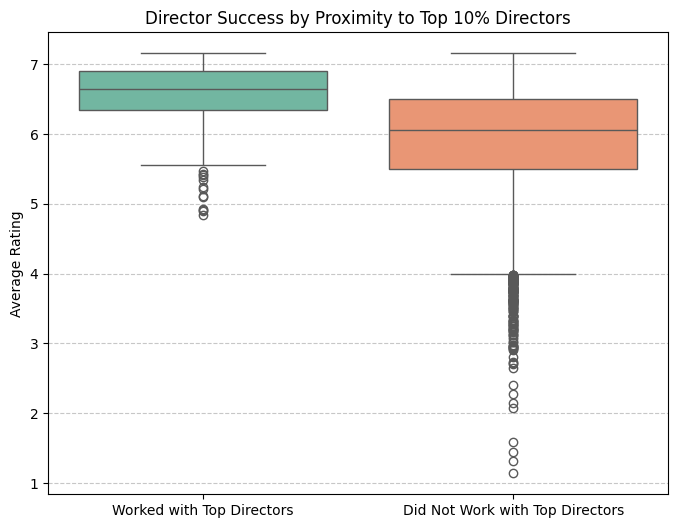


--- Analyzing Proximity to Success (Top 10%) ---
Note: Excluding movies co-directed with top directors from non-top directors' averages.
Rating threshold for top 10%: 7.16

Non-top directors who WORKED WITH top directors: 345
Average Rating: 6.4628 (Global Percentile: 65.6th)

Non-top directors who DID NOT work with top directors: 7171
Average Rating: 5.9220 (Global Percentile: 39.3th)


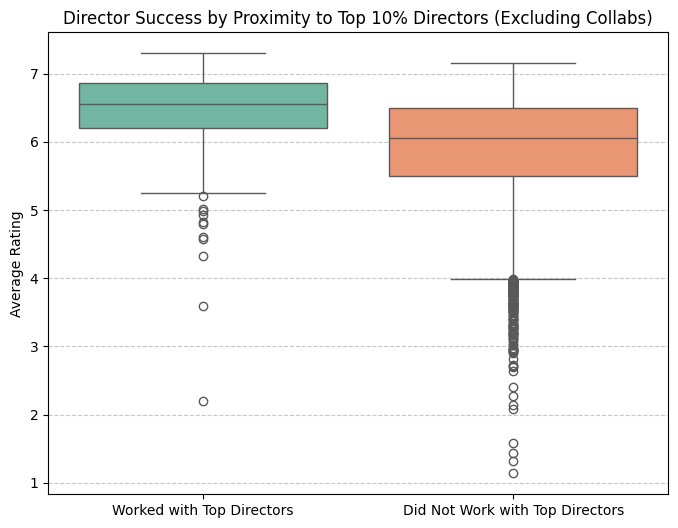

In [ ]:
def analyze_proximity_to_success(percentile=90, exclude_collabs=False):
    print(f"--- Analyzing Proximity to Success (Top {100-percentile}%) ---")
    if exclude_collabs:
        print("Note: Excluding movies co-directed with top directors from non-top directors' averages.")

    # Determine the rating threshold for the top-nth percentile
    threshold = np.percentile(director_avg_ratings['directorAvgRating'], percentile)
    print(f"Rating threshold for top {100-percentile}%: {threshold:.2f}")

    # Identify top directors and non-top directors
    top_directors = set(director_avg_ratings[director_avg_ratings['directorAvgRating'] >= threshold]['nconst'])
    non_top_directors = set(director_avg_ratings[director_avg_ratings['directorAvgRating'] < threshold]['nconst'])

    # Filter to only include directors that are actually in the graph
    graph_nodes = set(director_graph.nodes())
    top_directors = top_directors.intersection(graph_nodes)
    non_top_directors = non_top_directors.intersection(graph_nodes)

    # Find non-top directors who have worked with at least one top director
    connected_to_top = []
    not_connected_to_top = []

    for d in non_top_directors:
        # Check neighbors in the graph
        neighbors = set(director_graph.neighbors(d))
        if neighbors.intersection(top_directors):
            connected_to_top.append(d)
        else:
            not_connected_to_top.append(d)

    # Compute the average ratings for both groups
    if exclude_collabs:
        # Find all movies that have at least one top director
        top_director_movies = set(director_ratings[director_ratings['nconst'].isin(top_directors)]['tconst'])

        # Filter director_ratings to exclude these movies
        filtered_ratings = director_ratings[~director_ratings['tconst'].isin(top_director_movies)]

        # Recalculate averages for non-top directors
        recalc_ratings = filtered_ratings[filtered_ratings['nconst'].isin(non_top_directors)].groupby('nconst')['averageRating'].mean().reset_index()

        connected_ratings = recalc_ratings[recalc_ratings['nconst'].isin(connected_to_top)]['averageRating']
        not_connected_ratings = recalc_ratings[recalc_ratings['nconst'].isin(not_connected_to_top)]['averageRating']
    else:
        connected_ratings = director_avg_ratings[director_avg_ratings['nconst'].isin(connected_to_top)]['directorAvgRating']
        not_connected_ratings = director_avg_ratings[director_avg_ratings['nconst'].isin(not_connected_to_top)]['directorAvgRating']

    # Drop NaNs just in case a connected director ONLY made movies with top directors and now has no ratings
    connected_ratings = connected_ratings.dropna()
    not_connected_ratings = not_connected_ratings.dropna()

    # Calculate percentiles
    connected_mean = connected_ratings.mean()
    not_connected_mean = not_connected_ratings.mean()

    from scipy import stats
    connected_pct = stats.percentileofscore(director_avg_ratings['directorAvgRating'].dropna(), connected_mean)
    not_connected_pct = stats.percentileofscore(director_avg_ratings['directorAvgRating'].dropna(), not_connected_mean)

    print(f"\nNon-top directors who WORKED WITH top directors: {len(connected_ratings)}")
    print(f"Average Rating: {connected_mean:.4f} (Global Percentile: {connected_pct:.1f}th)")

    print(f"\nNon-top directors who DID NOT work with top directors: {len(not_connected_ratings)}")
    print(f"Average Rating: {not_connected_mean:.4f} (Global Percentile: {not_connected_pct:.1f}th)")

    # Visualization
    plt.figure(figsize=(8, 6))
    # Convert Series to numpy arrays to prevent seaborn index alignment issues
    sns.boxplot(data=[connected_ratings.values, not_connected_ratings.values], palette='Set2')
    plt.xticks([0, 1], ['Worked with Top Directors', 'Did Not Work with Top Directors'])
    plt.ylabel('Average Rating')
    title_suffix = ' (Excluding Collabs)' if exclude_collabs else ''
    plt.title(f'Director Success by Proximity to Top {100-percentile}% Directors{title_suffix}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

print("="*100)
# Run the experiment with the 90th percentile (Top 10%), including direct collaborations
analyze_proximity_to_success(percentile=90, exclude_collabs=False)

print("\n" + "="*100)
# Run the experiment with the 90th percentile (Top 10%), excluding direct collaborations
analyze_proximity_to_success(percentile=90, exclude_collabs=True)


Ok, this ended up being a more telling experiment with a lot of potential for further exploration and tuning! This experiment was performed by selecting the directors in the 90th percentile of director ratings and building the subgraph containing them and their immediate neighbors. Next, the director ratings of all directors in the subgraph that were not "top-90th percentile" directors themselves was captured.

Interestingly, there is clear evidence that directors who collaborated with a top director also had above-average success in their own careers. And this observation still holds when factoring out the ratings of any movies where a director collaborated with a top director (i.e. eliminate the "riding on the coattails of someone else's success" effect); those who had collaborative experience with a "top-90th percentile" director fell within the top-65th percentile of all directors (after making the aforementioned adjustments to rating).

Let's next iterate through this experiment at different thresholds if this trend still holds...

Calculating proximity effect across different percentiles...


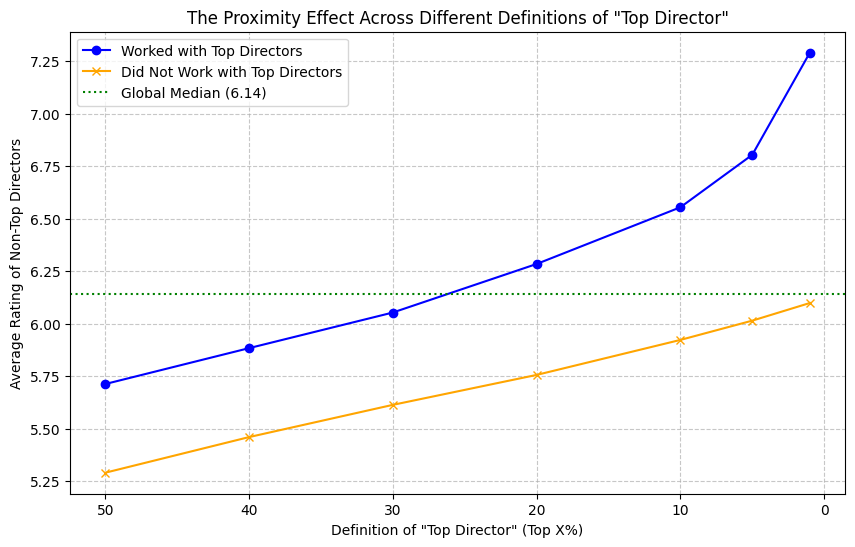

In [ ]:
percentiles_to_test = [50, 60, 70, 80, 90, 95, 99]
connected_means = []
not_connected_means = []

print("Calculating proximity effect across different percentiles...")
for pct in percentiles_to_test:
    threshold = np.percentile(director_avg_ratings['directorAvgRating'], pct)

    top_directors = set(director_avg_ratings[director_avg_ratings['directorAvgRating'] >= threshold]['nconst'])
    non_top_directors = set(director_avg_ratings[director_avg_ratings['directorAvgRating'] < threshold]['nconst'])

    graph_nodes = set(director_graph.nodes())
    top_directors = top_directors.intersection(graph_nodes)
    non_top_directors = non_top_directors.intersection(graph_nodes)

    connected_to_top = []
    not_connected_to_top = []

    for d in non_top_directors:
        neighbors = set(director_graph.neighbors(d))
        if neighbors.intersection(top_directors):
            connected_to_top.append(d)
        else:
            not_connected_to_top.append(d)

    c_mean = director_avg_ratings[director_avg_ratings['nconst'].isin(connected_to_top)]['directorAvgRating'].mean()
    nc_mean = director_avg_ratings[director_avg_ratings['nconst'].isin(not_connected_to_top)]['directorAvgRating'].mean()

    connected_means.append(c_mean)
    not_connected_means.append(nc_mean)

# Calculate global 50th percentile (median)
global_median = np.median(director_avg_ratings['directorAvgRating'].dropna())

# Plotting the trend
top_x_labels = [100 - p for p in percentiles_to_test]

plt.figure(figsize=(10, 6))
plt.plot(top_x_labels, connected_means, marker='o', label='Worked with Top Directors', color='blue')
plt.plot(top_x_labels, not_connected_means, marker='x', label='Did Not Work with Top Directors', color='orange')

# Add horizontal line for global median
plt.axhline(y=global_median, color='green', linestyle=':', label=f'Global Median ({global_median:.2f})')

plt.gca().invert_xaxis()  # Invert x-axis so it goes from 50% down to 1%
plt.xlabel('Definition of "Top Director" (Top X%)')
plt.ylabel('Average Rating of Non-Top Directors')
plt.title('The Proximity Effect Across Different Definitions of "Top Director"')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Nice! The trend previously identified does appeart to hold strikingly well across a range of thresholds. One consideration that may negate the significance of these findings that needs to be evaluated:did above-average directors only get to collaborate with "top" directors *because* they were already above-average directors at the time of the collaboration? We'll explore this a little bit more below, starting initially with our original experiment that focused on 90th-percentile directors.

In [ ]:
# Determine the top 10% directors
threshold_90 = np.percentile(director_avg_ratings['directorAvgRating'], 90)

top_directors_df = director_avg_ratings[director_avg_ratings['directorAvgRating'] >= threshold_90]
non_top_directors_df = director_avg_ratings[director_avg_ratings['directorAvgRating'] < threshold_90]

top_director_ids = set(top_directors_df['nconst'])
non_top_director_ids = set(non_top_directors_df['nconst'])

# Filter director_ratings to find all movies directed by top directors
top_dir_movies = director_ratings[director_ratings['nconst'].isin(top_director_ids)][['tconst', 'nconst', 'startYear']]

# Join with non-top directors' ratings to identify collaborations
non_top_dir_movies = director_ratings[director_ratings['nconst'].isin(non_top_director_ids)][['tconst', 'nconst']]
collaborations = top_dir_movies.merge(non_top_dir_movies, on='tconst', suffixes=('_top', '_nontop'))

# Handle potential missing or non-numeric startYear values ('\N')
collaborations['startYear'] = pd.to_numeric(collaborations['startYear'], errors='coerce')
collaborations = collaborations.dropna(subset=['startYear'])

# Find the minimum startYear for each non-top director
first_collabs = collaborations.groupby('nconst_nontop')['startYear'].min().reset_index()
first_collabs.rename(columns={'nconst_nontop': 'nconst', 'startYear': 'first_collab_year'}, inplace=True)

print(f"Found {len(first_collabs)} non-top directors with at least one collaboration with a top director.")
display(first_collabs.head())


Found 305 non-top directors with at least one collaboration with a top director.


,nconst,first_collab_year
0,nm0000095,1989
1,nm0000338,1989
2,nm0000382,1991
3,nm0000419,1971
4,nm0000484,1983


In the above code, we capture for each director the first year in which they had a collaboration with a "top" director. If a director doesn't have a ny collaborations with a top director that include a `startYear` field, they are dropped from the set (which is why we have only 305 directors here instead of the 345/346 originally identified previously).

In [ ]:
# Merge director_ratings with first_collabs
merged_ratings = director_ratings.merge(first_collabs, on='nconst', how='inner')

# Ensure startYear is numeric
merged_ratings['startYear'] = pd.to_numeric(merged_ratings['startYear'], errors='coerce')
merged_ratings = merged_ratings.dropna(subset=['startYear'])

# Split into Before and After groups
before_mask = merged_ratings['startYear'] < merged_ratings['first_collab_year']
after_mask = merged_ratings['startYear'] >= merged_ratings['first_collab_year']

before_movies = merged_ratings[before_mask]
after_movies = merged_ratings[after_mask]

# Calculate mean averageRating for Before and After
before_avg = before_movies.groupby('nconst')['averageRating'].mean().reset_index()
before_avg.rename(columns={'averageRating': 'before_rating'}, inplace=True)

after_avg = after_movies.groupby('nconst')['averageRating'].mean().reset_index()
after_avg.rename(columns={'averageRating': 'after_rating'}, inplace=True)

# Merge Before and After ratings
pre_post_ratings = before_avg.merge(after_avg, on='nconst', how='inner')

# Display first few rows and print qualifying directors
print(f"Found {len(pre_post_ratings)} non-top directors with ratings before and after their first collaboration with a top director.")
display(pre_post_ratings.head())


Found 232 non-top directors with ratings before and after their first collaboration with a top director.


,nconst,before_rating,after_rating
0,nm0000095,7.200000,6.790909
1,nm0000338,6.427778,6.200000
2,nm0000382,6.733333,6.447059
3,nm0000419,6.785000,6.225000
4,nm0000484,6.940000,6.193333


For our experiment, we need to be able to isolate the effect of having worked with a top director on the director's career trajectory (i.e. remove directors who have no works after their collaboration).

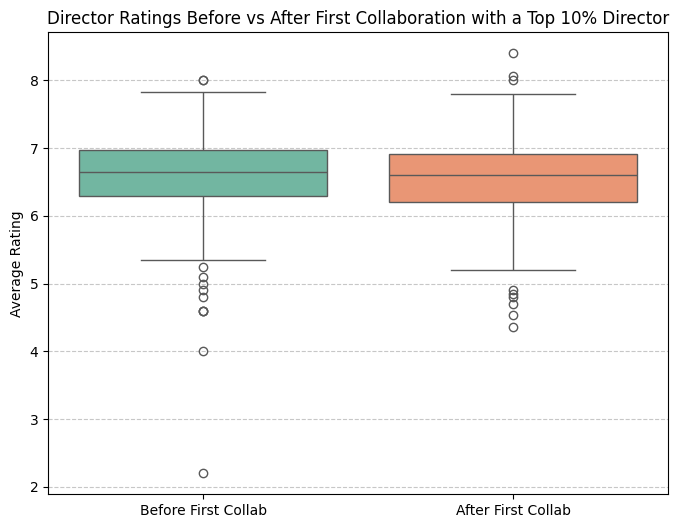


Paired t-test results:
t-statistic: 0.5196
p-value: 0.6038
Mean difference (After - Before): -0.0281

Conclusion: There is NO statistically significant difference in ratings before and after collaboration.


In [ ]:
# Reshape data for visualization
melted_ratings = pd.melt(pre_post_ratings, id_vars=['nconst'], value_vars=['before_rating', 'after_rating'],
                         var_name='Period', value_name='Rating')

# Replace variable names with more readable labels
melted_ratings['Period'] = melted_ratings['Period'].replace({'before_rating': 'Before First Collab', 'after_rating': 'After First Collab'})

# Create Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=melted_ratings, x='Period', y='Rating', hue='Period', palette='Set2', legend=False)
plt.title('Director Ratings Before vs After First Collaboration with a Top 10% Director')
plt.ylabel('Average Rating')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Perform Paired t-test
t_stat, p_val = stats.ttest_rel(pre_post_ratings['before_rating'], pre_post_ratings['after_rating'])

# Print results
print(f"\nPaired t-test results:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4g}")

mean_diff = pre_post_ratings['after_rating'].mean() - pre_post_ratings['before_rating'].mean()
print(f"Mean difference (After - Before): {mean_diff:.4f}")

if p_val < 0.05:
    print("\nConclusion: There is a statistically significant difference in ratings before and after collaboration.")
else:
    print("\nConclusion: There is NO statistically significant difference in ratings before and after collaboration.")

Bummer...Our analysis does seem to suggest that the previous concern of above-average directors only getting to work with top directors in large part because they were already above-average directors at the time of the colalboration is founded. While this experiment didn't result in arriving at a meaningful predictor for director success, it does appear to reveal some degree of selection bias in who gets to work with top directors.

So we can't use PageRank or "proximity to greatness" as a mechanism for predicting director success - let's try one more approach: community size as a predictor. The hypothesis is that, if there is a correlation between community size and director success, then it will be the larger communities that perform better (rationale: directors in larger clusters may have access to more talent, more opportunities for repeated, successful partnerships, etc.) . I'll use the Louvain algorithm for categorizing nodes into communities and evaluate for a correlative effect.

In [ ]:
# Install python-louvain for community detection
!pip install python-louvain

Detecting communities in the director graph...
Detected 4011 communities.

Pearson Correlation (Community Size vs. Average Normalized Rating): -0.0035
Spearman Correlation (Community Size vs. Average Normalized Rating): -0.0058


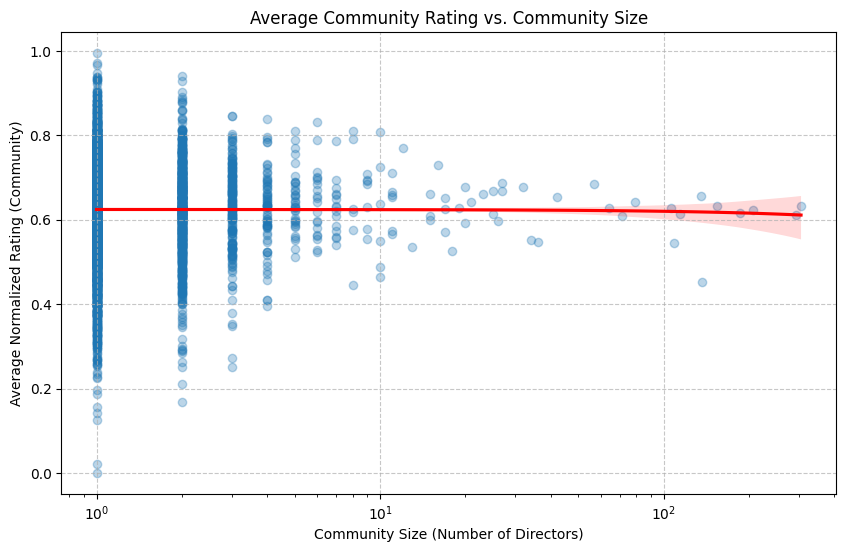

In [ ]:
# Find communities using the Louvain method
print("Detecting communities in the director graph...")
partition = cl.best_partition(director_graph)

# Convert partition to a DataFrame
community_df = pd.DataFrame(list(partition.items()), columns=['nconst', 'community_id'])

# Merge with director success data
# We'll use merged_df as it contains normalizedRating
community_success_df = merged_df.merge(community_df, on='nconst', how='inner')

print(f"Detected {community_success_df['community_id'].nunique()} communities.")

# Calculate average normalized rating for each community
community_avg_success = community_success_df.groupby('community_id')['normalizedRating'].mean().reset_index()
community_avg_success.rename(columns={'normalizedRating': 'avg_community_rating'}, inplace=True)

# Let's see: Do larger communities correlate with higher success?
community_size = community_success_df.groupby('community_id').size().reset_index(name='community_size')
community_stats = community_avg_success.merge(community_size, on='community_id')

pearson_corr_community_size = community_stats['avg_community_rating'].corr(community_stats['community_size'])
spearman_corr_community_size = community_stats['avg_community_rating'].corr(community_stats['community_size'], method='spearman')

print(f"\nPearson Correlation (Community Size vs. Average Normalized Rating): {pearson_corr_community_size:.4f}")
print(f"Spearman Correlation (Community Size vs. Average Normalized Rating): {spearman_corr_community_size:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=community_stats, x='community_size', y='avg_community_rating', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Average Community Rating vs. Community Size')
plt.xlabel('Community Size (Number of Directors)')
plt.ylabel('Average Normalized Rating (Community)')
plt.xscale('log') # Log scale for community size as it can vary widely
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

We appear to have hit a dead-end here as well...I'm not sure I'm too optimistic that the results on the actor interaction graph will be much different, but let's check to be thorough.

## 2e. Actor Population- Analysis

In [ ]:
actor_pkl_path = DRIVE_DIR + PROJECT_DIR + "/actor_analysis_results.pkl"

# For this experiment I also add an option to just import the results from a .pkl
# file. The actor interaction graph is larger than the director graph, and the
# Louvain computation for community detection was taking about 40 mins.
# Don't want to have to wait for that to run everytime I run this cell
if LOAD_FROM_PKL and os.path.exists(actor_pkl_path):
  print(f"Loading actor analysis results from {actor_pkl_path}...")
  with open(actor_pkl_path, "rb") as f:
    actor_analysis_results = pickle.load(f)

  actor_avg_ratings = actor_analysis_results["actor_avg_ratings"]
  actor_pagerank = actor_analysis_results["actor_pagerank"]
  actor_merged_df = actor_analysis_results["actor_merged_df"]
  threshold_90 = actor_analysis_results["threshold_90"]
  conn_ratings = actor_analysis_results["conn_ratings"]
  not_conn_ratings = actor_analysis_results["not_conn_ratings"]
  actor_partition = actor_analysis_results["actor_partition"]
  actor_comm_stats = actor_analysis_results["actor_comm_stats"]

  print("Successfully loaded results from pickle!\n")

  print("=== Candidate Actor Detection ===")
  print(f"Number of actors with >= 5 movies: {len(actor_avg_ratings)}\n")

  print("=== PageRank vs Success ===")
  pearson_corr_pr = actor_merged_df['normalizedRating'].corr(actor_merged_df['pageRank'])
  spearman_corr_pr = actor_merged_df['normalizedRating'].corr(actor_merged_df['pageRank'], method='spearman')
  print(f"Pearson Correlation (Linear): {pearson_corr_pr:.4f}")
  print(f"Spearman Correlation (Monotonic): {spearman_corr_pr:.4f}\n")

  print("=== Proximity to Success (Top 10%) ===")
  print(f"Rating threshold for top 10% actors: {threshold_90:.2f}")
  print(f"Non-top actors who WORKED WITH top actors: {len(conn_ratings)} (Average Rating: {conn_ratings.mean():.4f})")
  print(f"Non-top actors who DID NOT work with top actors: {len(not_conn_ratings)} (Average Rating: {not_conn_ratings.mean():.4f})\n")

  print("=== Community Detection ===")
  print(f"Detected {actor_comm_stats.shape[0]} communities.")
  pearson_corr_comm = actor_comm_stats['normalizedRating'].corr(actor_comm_stats['community_size'])
  spearman_corr_comm = actor_comm_stats['normalizedRating'].corr(actor_comm_stats['community_size'], method='spearman')
  print(f"Pearson Correlation (Community Size vs. Avg Rating): {pearson_corr_comm:.4f}")
  print(f"Spearman Correlation (Community Size vs. Avg Rating): {spearman_corr_comm:.4f}")
else:
  print("=== Candidate Actor Detection ===")
  # Merge actors with ratings
  actor_ratings = actors.merge(ratings, on="tconst", how="inner")

  # Calculate average rating and movie count per actor
  actor_stats = actor_ratings.groupby("nconst").agg(
    actorAvgRating=("averageRating", "mean"),
    numMoviesActed=("tconst", "nunique")
  ).reset_index()

  # Map to primaryName and filter for >= 5 movies
  actor_avg_ratings = actor_stats.merge(names[['nconst', 'primaryName']], on='nconst', how='left')
  actor_avg_ratings = actor_avg_ratings[actor_avg_ratings["numMoviesActed"] >= 5]
  print(f"Number of actors with >= 5 movies: {len(actor_avg_ratings)}\n")

  print("=== PageRank vs Success ===")
  print("Computing PageRank for actors (this may take a few minutes)...")
  start_time = time.time()
  actor_pagerank = nx.pagerank(actor_graph, weight='weight')
  print(f"PageRank computed in {time.time() - start_time:.2f} seconds.")

  # Convert to DataFrame and merge
  actor_pr_df = pd.DataFrame(list(actor_pagerank.items()), columns=['nconst', 'pageRank'])
  actor_merged_df = actor_avg_ratings.merge(actor_pr_df, on='nconst', how='inner')

  # Normalize ratings
  scaler = MinMaxScaler()
  actor_merged_df['normalizedRating'] = scaler.fit_transform(actor_merged_df[['actorAvgRating']])
  actor_merged_df['logPageRank'] = np.log10(actor_merged_df['pageRank'])

  pearson_corr_pr = actor_merged_df['normalizedRating'].corr(actor_merged_df['pageRank'])
  spearman_corr_pr = actor_merged_df['normalizedRating'].corr(actor_merged_df['pageRank'], method='spearman')
  print(f"Pearson Correlation (Linear): {pearson_corr_pr:.4f}")
  print(f"Spearman Correlation (Monotonic): {spearman_corr_pr:.4f}\n")

  print("=== Proximity to Success (Top 10%) ===")
  # Threshold for top 10%
  threshold_90 = np.percentile(actor_avg_ratings['actorAvgRating'].dropna(), 90)
  print(f"Rating threshold for top 10% actors: {threshold_90:.2f}")

  # Identify top and non-top actors (filtered by those in the graph)
  actor_graph_nodes = set(actor_graph.nodes())
  top_actors = set(actor_avg_ratings[actor_avg_ratings['actorAvgRating'] >= threshold_90]['nconst']).intersection(actor_graph_nodes)
  non_top_actors = set(actor_avg_ratings[actor_avg_ratings['actorAvgRating'] < threshold_90]['nconst']).intersection(actor_graph_nodes)

  connected_to_top_actors = []
  not_connected_to_top_actors = []

  print("Checking actor proximity (this may take a moment)...")
  for a in non_top_actors:
    neighbors = set(actor_graph.neighbors(a))
    if neighbors.intersection(top_actors):
      connected_to_top_actors.append(a)
    else:
      not_connected_to_top_actors.append(a)

  conn_ratings = actor_avg_ratings[actor_avg_ratings['nconst'].isin(connected_to_top_actors)]['actorAvgRating'].dropna()
  not_conn_ratings = actor_avg_ratings[actor_avg_ratings['nconst'].isin(not_connected_to_top_actors)]['actorAvgRating'].dropna()

  print(f"Non-top actors who WORKED WITH top actors: {len(conn_ratings)} (Average Rating: {conn_ratings.mean():.4f})")
  print(f"Non-top actors who DID NOT work with top actors: {len(not_conn_ratings)} (Average Rating: {not_conn_ratings.mean():.4f})\n")

  print("=== Community Detection ===")
  print("Detecting communities in the actor graph using Louvain method (this will take several minutes)...")
  start_time = time.time()
  actor_partition = cl.best_partition(actor_graph)
  print(f"Communities detected in {time.time() - start_time:.2f} seconds.")

  actor_comm_df = pd.DataFrame(list(actor_partition.items()), columns=['nconst', 'community_id'])
  actor_comm_success = actor_merged_df.merge(actor_comm_df, on='nconst', how='inner')

  # Calculate average rating per community and merge with size
  actor_comm_avg = actor_comm_success.groupby('community_id')['normalizedRating'].mean().reset_index()
  actor_comm_size = actor_comm_success.groupby('community_id').size().reset_index(name='community_size')
  actor_comm_stats = actor_comm_avg.merge(actor_comm_size, on='community_id')

  print(f"Detected {actor_comm_stats.shape[0]} communities.")
  pearson_corr_comm = actor_comm_stats['normalizedRating'].corr(actor_comm_stats['community_size'])
  spearman_corr_comm = actor_comm_stats['normalizedRating'].corr(actor_comm_stats['community_size'], method='spearman')
  print(f"Pearson Correlation (Community Size vs. Avg Rating): {pearson_corr_comm:.4f}")
  print(f"Spearman Correlation (Community Size vs. Avg Rating): {spearman_corr_comm:.4f}")

Loading actor analysis results from /content/drive/MyDrive/CSCE_676/Project/actor_analysis_results.pkl...
Successfully loaded results from pickle!

=== Candidate Actor Detection ===
Number of actors with >= 5 movies: 101932

=== PageRank vs Success ===
Pearson Correlation (Linear): 0.0124
Spearman Correlation (Monotonic): 0.0128

=== Proximity to Success (Top 10%) ===
Rating threshold for top 10% actors: 6.71
Non-top actors who WORKED WITH top actors: 57082 (Average Rating: 5.9638)
Non-top actors who DID NOT work with top actors: 34654 (Average Rating: 5.4261)

=== Community Detection ===
Detected 118 communities.
Pearson Correlation (Community Size vs. Avg Rating): -0.1388
Spearman Correlation (Community Size vs. Avg Rating): -0.3185


Found 54330 non-top actors with at least one collaboration with a top actor.
Found 35678 non-top actors with ratings before and after their first collaboration with a top actor.


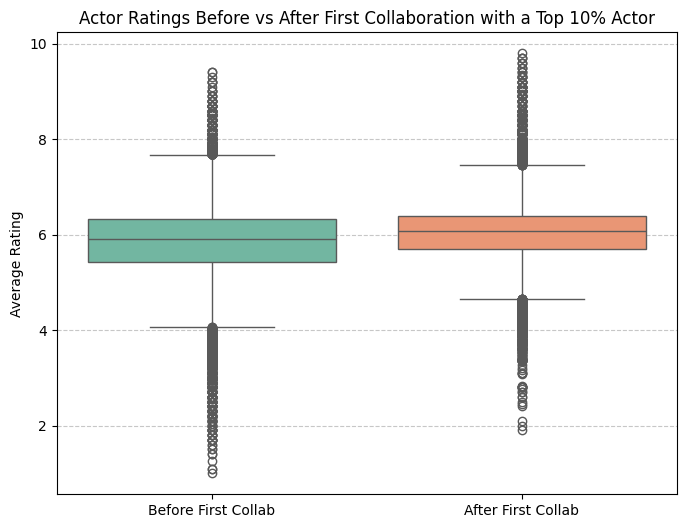


Paired t-test results:
t-statistic: -38.3212
p-value: 0
Mean difference (After - Before): 0.1987

Conclusion: There is a statistically significant difference in ratings before and after collaboration.


In [ ]:
# Determine the top 10% actors
threshold_90_actor = np.percentile(actor_avg_ratings['actorAvgRating'].dropna(), 90)

top_actors_df = actor_avg_ratings[actor_avg_ratings['actorAvgRating'] >= threshold_90_actor]
non_top_actors_df = actor_avg_ratings[actor_avg_ratings['actorAvgRating'] < threshold_90_actor]

top_actor_ids = set(top_actors_df['nconst'])
non_top_actor_ids = set(non_top_actors_df['nconst'])

# Ensure we have startYear attached to the ratings for actors
# 'actors' dataframe contains the startYear from previous merges, 'ratings' has the averageRating
actor_ratings_with_year = actors.merge(ratings, on='tconst', how='inner')

# Filter to find all movies acted in by top actors
top_act_movies = actor_ratings_with_year[actor_ratings_with_year['nconst'].isin(top_actor_ids)][['tconst', 'nconst', 'startYear']]

# Join with non-top actors' ratings to identify collaborations
non_top_act_movies = actor_ratings_with_year[actor_ratings_with_year['nconst'].isin(non_top_actor_ids)][['tconst', 'nconst']]
collaborations_act = top_act_movies.merge(non_top_act_movies, on='tconst', suffixes=('_top', '_nontop'))

# Handle potential missing or non-numeric startYear values ('\N')
collaborations_act['startYear'] = pd.to_numeric(collaborations_act['startYear'], errors='coerce')
collaborations_act = collaborations_act.dropna(subset=['startYear'])

# Find the minimum startYear for each non-top actor (their first collaboration)
first_collabs_act = collaborations_act.groupby('nconst_nontop')['startYear'].min().reset_index()
first_collabs_act.rename(columns={'nconst_nontop': 'nconst', 'startYear': 'first_collab_year'}, inplace=True)

print(f"Found {len(first_collabs_act)} non-top actors with at least one collaboration with a top actor.")

# Merge actor_ratings with first_collabs
merged_act_ratings = actor_ratings_with_year.merge(first_collabs_act, on='nconst', how='inner')

# Ensure startYear is numeric
merged_act_ratings['startYear'] = pd.to_numeric(merged_act_ratings['startYear'], errors='coerce')
merged_act_ratings = merged_act_ratings.dropna(subset=['startYear'])

# Split into Before and After groups
before_mask_act = merged_act_ratings['startYear'] < merged_act_ratings['first_collab_year']
after_mask_act = merged_act_ratings['startYear'] >= merged_act_ratings['first_collab_year']

before_movies_act = merged_act_ratings[before_mask_act]
after_movies_act = merged_act_ratings[after_mask_act]

# Calculate mean averageRating for Before and After
before_avg_act = before_movies_act.groupby('nconst')['averageRating'].mean().reset_index()
before_avg_act.rename(columns={'averageRating': 'before_rating'}, inplace=True)

after_avg_act = after_movies_act.groupby('nconst')['averageRating'].mean().reset_index()
after_avg_act.rename(columns={'averageRating': 'after_rating'}, inplace=True)

# Merge Before and After ratings
pre_post_act_ratings = before_avg_act.merge(after_avg_act, on='nconst', how='inner')

print(f"Found {len(pre_post_act_ratings)} non-top actors with ratings before and after their first collaboration with a top actor.")

# Reshape data for visualization
melted_act_ratings = pd.melt(pre_post_act_ratings, id_vars=['nconst'], value_vars=['before_rating', 'after_rating'],
                         var_name='Period', value_name='Rating')

# Replace variable names with more readable labels
melted_act_ratings['Period'] = melted_act_ratings['Period'].replace({'before_rating': 'Before First Collab', 'after_rating': 'After First Collab'})

# Create Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=melted_act_ratings, x='Period', y='Rating', hue='Period', palette='Set2', legend=False)
plt.title('Actor Ratings Before vs After First Collaboration with a Top 10% Actor')
plt.ylabel('Average Rating')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Perform Paired t-test
t_stat_act, p_val_act = stats.ttest_rel(pre_post_act_ratings['before_rating'], pre_post_act_ratings['after_rating'])

# Print results
print(f"\nPaired t-test results:")
print(f"t-statistic: {t_stat_act:.4f}")
print(f"p-value: {p_val_act:.4g}")

mean_diff_act = pre_post_act_ratings['after_rating'].mean() - pre_post_act_ratings['before_rating'].mean()
print(f"Mean difference (After - Before): {mean_diff_act:.4f}")

if p_val_act < 0.05:
    print("\nConclusion: There is a statistically significant difference in ratings before and after collaboration.")
else:
    print("\nConclusion: There is NO statistically significant difference in ratings before and after collaboration.")

This looks more promising! But, now I also want to make sure that this bump in rating after collabortaion can't be attributed to typical career progression effects (maybe an actor is expected to see their ratings improve with time). So, now I need to compare against a control population (i.e. those without any collaborative works with actors in the top 10%). For the control population, they have no true "before and after" dates for evaluating rating progression post-collab (because there are no collaborations to reference), so I'll use the median year of their career as the point in time by which we'll evaluate the change in their ratings

Found 37408 control actors.
Found 36733 control actors with ratings in both halves of their career.

--- Control Group (Never worked with top 10%) ---
Paired t-test results:
t-statistic: 21.0488
p-value: 8.872e-98
Mean difference (After - Before): -0.1023


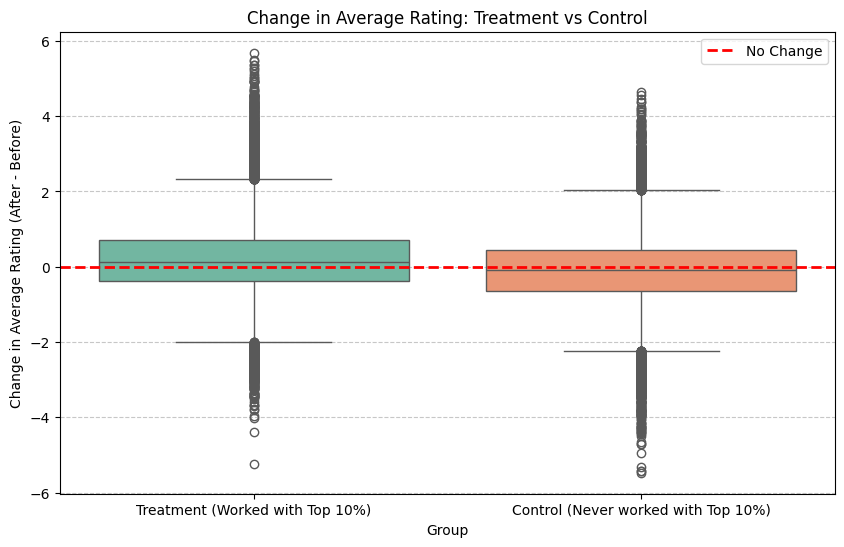

In [ ]:
# Identify control group: non-top actors who NEVER collaborated with a top 10% actor
# 'first_collabs_act' contains those who DID collaborate.
treatment_actors = set(first_collabs_act['nconst'])
control_actors = non_top_actor_ids - treatment_actors

# Filter ratings for control actors
control_movies = actor_ratings_with_year[actor_ratings_with_year['nconst'].isin(control_actors)].copy()
control_movies['startYear'] = pd.to_numeric(control_movies['startYear'], errors='coerce')
control_movies = control_movies.dropna(subset=['startYear'])

# Find the midpoint of their career to act as a pseudo-intervention year
# Using the median startYear for each actor
career_midpoints = control_movies.groupby('nconst')['startYear'].median().reset_index()
career_midpoints.rename(columns={'startYear': 'pseudo_collab_year'}, inplace=True)

print(f"Found {len(career_midpoints)} control actors.")

# Merge to get the pseudo year
merged_control_ratings = control_movies.merge(career_midpoints, on='nconst', how='inner')

# Split into Before and After
before_mask_ctrl = merged_control_ratings['startYear'] < merged_control_ratings['pseudo_collab_year']
after_mask_ctrl = merged_control_ratings['startYear'] >= merged_control_ratings['pseudo_collab_year']

before_movies_ctrl = merged_control_ratings[before_mask_ctrl]
after_movies_ctrl = merged_control_ratings[after_mask_ctrl]

# Calculate means for Before and After
before_avg_ctrl = before_movies_ctrl.groupby('nconst')['averageRating'].mean().reset_index()
before_avg_ctrl.rename(columns={'averageRating': 'before_rating'}, inplace=True)

after_avg_ctrl = after_movies_ctrl.groupby('nconst')['averageRating'].mean().reset_index()
after_avg_ctrl.rename(columns={'averageRating': 'after_rating'}, inplace=True)

# Merge
pre_post_ctrl_ratings = before_avg_ctrl.merge(after_avg_ctrl, on='nconst', how='inner')

print(f"Found {len(pre_post_ctrl_ratings)} control actors with ratings in both halves of their career.")

# Paired t-test for control group
t_stat_ctrl, p_val_ctrl = stats.ttest_rel(pre_post_ctrl_ratings['before_rating'], pre_post_ctrl_ratings['after_rating'])
mean_diff_ctrl = pre_post_ctrl_ratings['after_rating'].mean() - pre_post_ctrl_ratings['before_rating'].mean()

print(f"\n--- Control Group (Never worked with top 10%) ---")
print(f"Paired t-test results:")
print(f"t-statistic: {t_stat_ctrl:.4f}")
print(f"p-value: {p_val_ctrl:.4g}")
print(f"Mean difference (After - Before): {mean_diff_ctrl:.4f}")

# Visual Comparison of Differences
pre_post_act_ratings['Group'] = 'Treatment (Worked with Top 10%)'
pre_post_ctrl_ratings['Group'] = 'Control (Never worked with Top 10%)'

pre_post_act_ratings['Diff'] = pre_post_act_ratings['after_rating'] - pre_post_act_ratings['before_rating']
pre_post_ctrl_ratings['Diff'] = pre_post_ctrl_ratings['after_rating'] - pre_post_ctrl_ratings['before_rating']

combined_diff = pd.concat([pre_post_act_ratings[['Group', 'Diff']], pre_post_ctrl_ratings[['Group', 'Diff']]])

plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_diff, x='Group', y='Diff', hue='Group', palette='Set2', legend=False)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='No Change')
plt.title('Change in Average Rating: Treatment vs Control')
plt.ylabel('Change in Average Rating (After - Before)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


This is reassuring! Interestingly, we can observe in the control population that their ratings tend to go *down* in the latter half of their careers. Now, as we've done previously for the director data, let's use different values for $x$ and run the original experiment comparing ratings of actors with collaborations among the top $x$-percent of actors to those without collaborations.

Calculating proximity effect across different percentiles for actors...


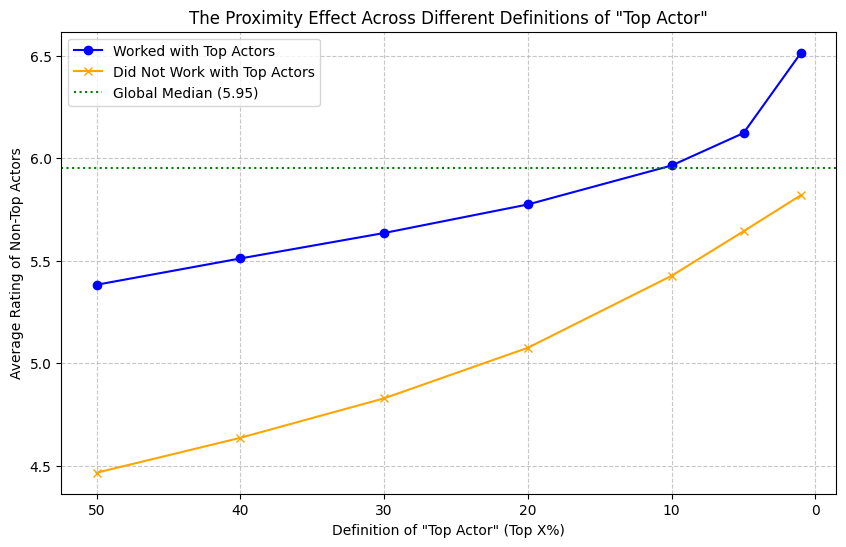

In [ ]:
percentiles_to_test = [50, 60, 70, 80, 90, 95, 99]
connected_means_act = []
not_connected_means_act = []

print("Calculating proximity effect across different percentiles for actors...")
actor_graph_nodes = set(actor_graph.nodes())

for pct in percentiles_to_test:
  threshold = np.percentile(actor_avg_ratings['actorAvgRating'].dropna(), pct)

  top_actors = set(actor_avg_ratings[actor_avg_ratings['actorAvgRating'] >= threshold]['nconst']).intersection(actor_graph_nodes)
  non_top_actors = set(actor_avg_ratings[actor_avg_ratings['actorAvgRating'] < threshold]['nconst']).intersection(actor_graph_nodes)

  # Optimized neighbor checking using sets to handle the massive actor graph
  top_actor_neighbors = set()
  for ta in top_actors:
      top_actor_neighbors.update(actor_graph.neighbors(ta))

  connected_to_top = non_top_actors.intersection(top_actor_neighbors)
  not_connected_to_top = non_top_actors - connected_to_top

  c_mean = actor_avg_ratings[actor_avg_ratings['nconst'].isin(connected_to_top)]['actorAvgRating'].mean()
  nc_mean = actor_avg_ratings[actor_avg_ratings['nconst'].isin(not_connected_to_top)]['actorAvgRating'].mean()

  connected_means_act.append(c_mean)
  not_connected_means_act.append(nc_mean)

# Calculate global 50th percentile (median)
global_median_act = np.median(actor_avg_ratings['actorAvgRating'].dropna())

# Plotting the trend
top_x_labels = [100 - p for p in percentiles_to_test]

plt.figure(figsize=(10, 6))
plt.plot(top_x_labels, connected_means_act, marker='o', label='Worked with Top Actors', color='blue')
plt.plot(top_x_labels, not_connected_means_act, marker='x', label='Did Not Work with Top Actors', color='orange')

# Add horizontal line for global median
plt.axhline(y=global_median_act, color='green', linestyle=':', label=f'Global Median ({global_median_act:.2f})')

plt.gca().invert_xaxis()  # Invert x-axis so it goes from 50% down to 1%
plt.xlabel('Definition of "Top Actor" (Top X%)')
plt.ylabel('Average Rating of Non-Top Actors')
plt.title('The Proximity Effect Across Different Definitions of "Top Actor"')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


No surprise, as with the director data, we can observe that those with collaborations with actors in the top $x$-percent have higher average ratings than those who do not. Though, as we've explored previously, for the actor dataset, this is not merely selection bias but instead what appears to be a genuine effect of getting to work with "successful" peers.

# 3. Observations/Conclusion

## 3a. Summary of Findings

#### PageRank
<table style="width:100%; border-collapse: collapse;">
  <tr>
    <th style="text-align:left; border: 1px solid #dddddd; padding: 8px; width: 15%;">Population</th>
    <th style="text-align:left; border: 1px solid #dddddd; padding: 8px; width: 85%;">Findings</th>
  </tr>
  <tr>
    <td style="border: 1px solid #dddddd; padding: 8px;"><strong>Director</strong></td>
    <td style="border: 1px solid #dddddd; padding: 8px;">No significant correlation was found between a director's structural importance (PageRank) and their career success (average ratings).</td>
  </tr>
  <tr>
    <td style="border: 1px solid #dddddd; padding: 8px;"><strong>Actor</strong></td>
    <td style="border: 1px solid #dddddd; padding: 8px;">Similar to directors, global graph metrics like PageRank were not strong predictors of individual success.</td>
  </tr>
</table>

<br>

#### Community Size
<table style="width:100%; border-collapse: collapse;">
  <tr>
    <th style="text-align:left; border: 1px solid #dddddd; padding: 8px; width: 15%;">Population</th>
    <th style="text-align:left; border: 1px solid #dddddd; padding: 8px; width: 85%;">Findings</th>
  </tr>
  <tr>
    <td style="border: 1px solid #dddddd; padding: 8px;"><strong>Director</strong></td>
    <td style="border: 1px solid #dddddd; padding: 8px;">No significant correlation was found between the size of their professional community and their career success.</td>
  </tr>
  <tr>
    <td style="border: 1px solid #dddddd; padding: 8px;"><strong>Actor</strong></td>
    <td style="border: 1px solid #dddddd; padding: 8px;">Similar to directors, community size was not a strong predictor of individual success.</td>
  </tr>
</table>

<br>

### Proximity to Success
<table style="width:100%; border-collapse: collapse;">
  <tr>
    <th style="text-align:left; border: 1px solid #dddddd; padding: 8px; width: 15%;">Population</th>
    <th style="text-align:left; border: 1px solid #dddddd; padding: 8px; width: 85%;">Findings</th>
  </tr>
  <tr>
    <td style="border: 1px solid #dddddd; padding: 8px;"><strong>Director</strong></td>
    <td style="border: 1px solid #dddddd; padding: 8px;">While directors who collaborated with top-tier (90th percentile) directors generally had higher ratings, a longitudinal analysis showed no significant improvement in ratings <em>after</em> the collaboration.<br><br>This suggests a <strong>selection bias</strong>: high-performing directors are simply more likely to be chosen for collaborations with other top directors.</td>
  </tr>
  <tr>
    <td style="border: 1px solid #dddddd; padding: 8px;"><strong>Actor</strong></td>
    <td style="border: 1px solid #dddddd; padding: 8px;">Unlike the director population, actors showed a <strong>statistically significant increase</strong> in their average ratings following their first collaboration with a top-10% actor.<br><br><strong>Control Comparison:</strong> When compared against a control group (actors who never worked with top-tier peers), the difference was stark: the 'treatment' group saw a rating bump, while the control group's ratings typically declined in the latter half of their careers.<br><br>This suggests that for actors, proximity to successful peers may be a genuine catalyst for career success.</td>
  </tr>
</table>

# 4. Collaboration Declaration

1.   Collaborators: N/A

2.   Web Sources:
     - IMDb Non-Commercial Dataset: https://developer.imdb.com/non-commercial-datasets/

3.   AI Tools:
     - Google Gemini: For assistance with experiment implementation (particularly with "proximity to success" experiment; calculating actor/director before and after collaboration scores) and creating plots with experiment data.

# 5. Miscellaneous

In [ ]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!python --version

Python 3.12.13
